In [2]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive

In [3]:
# drive.mount('/content/drive')
# df = pd.read_csv("/content/drive/My Drive/DataMiningProject/BankChurners.csv")

In [4]:
path = "BankChurners_clean.csv"
df = pd.read_csv(path)
print("Shape (rows, cols):", df.shape)
df.head()

Shape (rows, cols): (17000, 21)


,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition_Flag
0,768805383,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,Existing Customer
1,818770008,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,Existing Customer
2,713982108,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,Existing Customer
3,769911858,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,Existing Customer
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,Existing Customer


In [5]:
#Check again for missing values and duplicates
print("NaN rows:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum().sum())
print("=" * 60)
#Check the datatypes of the columns
print(df.dtypes)


NaN rows: 0
Duplicate rows: 0
CLIENTNUM                     int64
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
Attrition_Flag               object
dtype: object


In [6]:
#Categorical columns
print("Categorical columns:")
cat_col = df.select_dtypes(include='object').columns
print(cat_col)
print("=" * 60)

#Numeric columns
print("\nNumeric columns:")
num_col = df.select_dtypes(include='number').columns
print(num_col)

Categorical columns:
Index(['Gender', 'Education_Level', 'Marital_Status', 'Income_Category',
       'Card_Category', 'Attrition_Flag'],
      dtype='object')

Numeric columns:
Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')


#### Simple analysis for categorical attributes

In [7]:
#Print unique values and counts for each categorical column
for col in cat_col:
    print(f"\n{col}:")
    print("  Unique values:", df[col].unique())
    print("  Value counts:\n", df[col].value_counts())
    print("=" * 60)



Gender:
  Unique values: ['M' 'F']
  Value counts:
 Gender
F    11028
M     5972
Name: count, dtype: int64

Education_Level:
  Unique values: ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
  Value counts:
 Education_Level
Graduate         5336
High School      3396
Uneducated       2371
Unknown          1696
Post-Graduate    1535
College          1495
Doctorate        1171
Name: count, dtype: int64

Marital_Status:
  Unique values: ['Married' 'Single' 'Unknown' 'Divorced']
  Value counts:
 Marital_Status
Married     8878
Single      5840
Divorced    1504
Unknown      778
Name: count, dtype: int64

Income_Category:
  Unique values: ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
  Value counts:
 Income_Category
Less than $40K    5496
$80K - $120K      3409
$40K - $60K       3000
$60K - $80K       2719
Unknown           1221
$120K +           1155
Name: count, dtype: int64

Card_Category:
  Unique values: ['Blu

#### Simple analysis for numerical attributes

In [8]:
#Descriptive statistics for numeric features
df[num_col].drop(columns=['CLIENTNUM'], errors='ignore').describe().T[['min','max','mean','50%']]

,min,max,mean,50%
Customer_Age,26.0,73.000,46.280294,46.000000
Dependent_count,0.0,5.000,2.216882,2.000000
Months_on_book,13.0,56.000,35.853118,36.000000
Total_Relationship_Count,1.0,6.000,3.450706,3.000000
Months_Inactive_12_mon,0.0,6.000,2.355824,2.000000
Contacts_Count_12_mon,0.0,6.000,2.517353,3.000000
Credit_Limit,1438.3,34516.000,8215.233207,4678.705366
Total_Revolving_Bal,0.0,2517.000,960.405294,949.000000
Avg_Open_To_Buy,3.0,34516.000,7254.689331,3793.906032
Total_Amt_Chng_Q4_Q1,0.0,3.397,0.732205,0.722817


In [9]:
#Print unique values and counts for each categorical column
for col in num_col:
    if col != 'CLIENTNUM':  #Skip the CLIENTNUM column 
        print(f"\n{col}:")        
        print("Std Dev:", df[col].std())
        print("Q1:", df[col].quantile(0.25))
        print("Q3:", df[col].quantile(0.75))  
        print("ICR:", df[col].quantile(0.75) - df[col].quantile(0.25))    
        print("=" * 60)



Customer_Age:
Std Dev: 7.354772325045742
Q1: 41.0
Q3: 51.0
ICR: 10.0

Dependent_count:
Std Dev: 1.2115333642997823
Q1: 1.0
Q3: 3.0
ICR: 2.0

Months_on_book:
Std Dev: 7.476764543936317
Q1: 32.0
Q3: 40.0
ICR: 8.0

Total_Relationship_Count:
Std Dev: 1.511348749110638
Q1: 2.0
Q3: 5.0
ICR: 3.0

Months_Inactive_12_mon:
Std Dev: 0.9123162439158601
Q1: 2.0
Q3: 3.0
ICR: 1.0

Contacts_Count_12_mon:
Std Dev: 1.018416246058264
Q1: 2.0
Q3: 3.0
ICR: 1.0

Credit_Limit:
Std Dev: 8394.995167845957
Q1: 2612.7925553076025
Q3: 10254.75
ICR: 7641.957444692398

Total_Revolving_Bal:
Std Dev: 824.935969739046
Q1: 0.0
Q3: 1631.0
ICR: 1631.0

Avg_Open_To_Buy:
Std Dev: 8389.75863969201
Q1: 1580.9603901964947
Q3: 9359.01661104438
ICR: 7778.056220847886

Total_Amt_Chng_Q4_Q1:
Std Dev: 0.20688663805238516
Q1: 0.6089641948240272
Q3: 0.8431605941966019
ICR: 0.23419639937257475

Total_Trans_Amt:
Std Dev: 2953.684374885214
Q1: 2041.75
Q3: 4554.25
ICR: 2512.5

Total_Trans_Ct:
Std Dev: 22.070846031132522
Q1: 40.0
Q3: 72

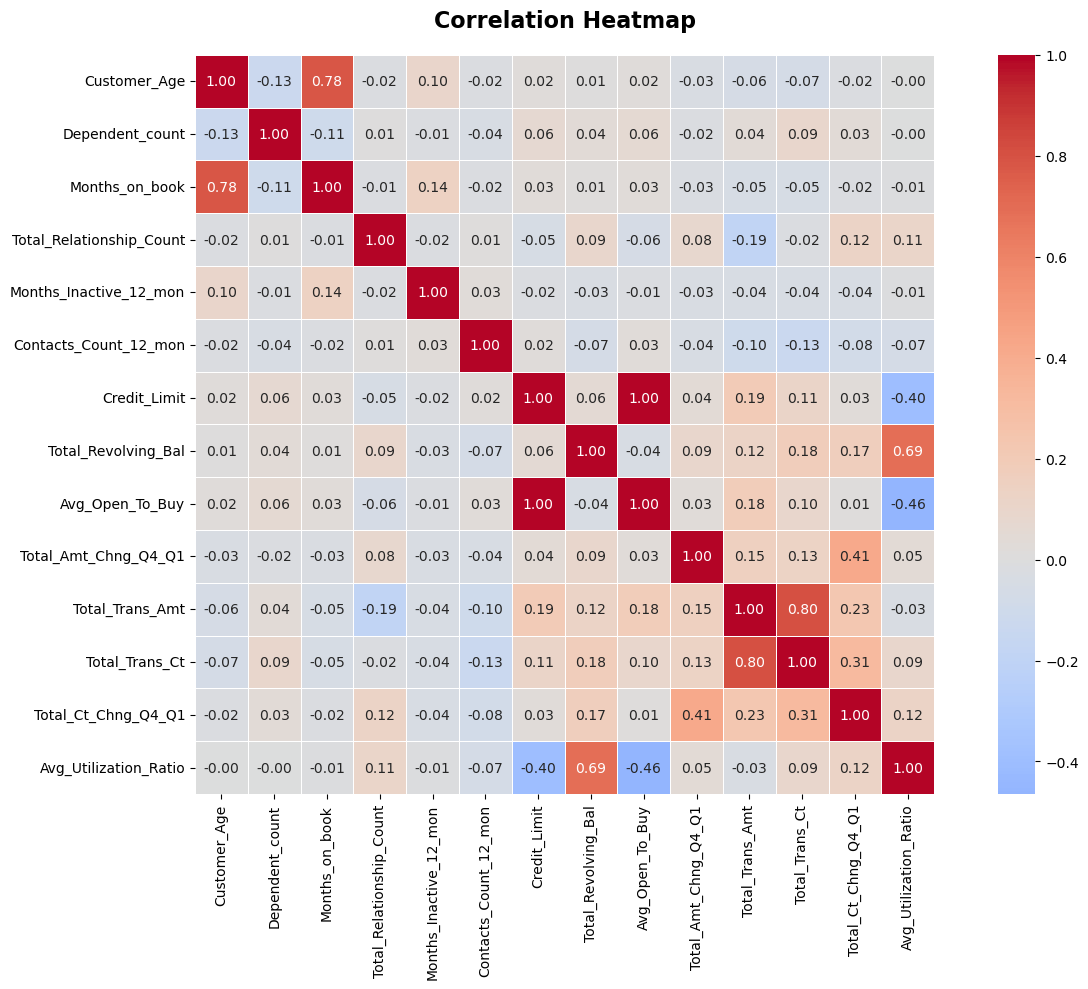


Positive correlations rank (ascending):
           Feature 1             Feature 2  Correlation
        Credit_Limit       Avg_Open_To_Buy     0.995169
     Total_Trans_Amt        Total_Trans_Ct     0.803983
        Customer_Age        Months_on_book     0.778713
 Total_Revolving_Bal Avg_Utilization_Ratio     0.689942
Total_Amt_Chng_Q4_Q1   Total_Ct_Chng_Q4_Q1     0.411388
      Total_Trans_Ct   Total_Ct_Chng_Q4_Q1     0.314631
     Total_Trans_Amt   Total_Ct_Chng_Q4_Q1     0.230430
        Credit_Limit       Total_Trans_Amt     0.194367
     Avg_Open_To_Buy       Total_Trans_Amt     0.182650
 Total_Revolving_Bal        Total_Trans_Ct     0.179174



In [10]:
#Correlation heatmap for numeric attributes
numeric_hm = df.select_dtypes(include='number').drop(columns=['CLIENTNUM'], errors='ignore')
correlation_matrix = numeric_hm.corr()

#Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True, #show values in cells
    fmt='.2f', #float
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#determine the top positive correlations (excluding diagonal)
print("\nPositive correlations rank (ascending):")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Feature 1': correlation_matrix.columns[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False) #Descending order
print(corr_df.head(10).to_string(index=False))
print("\n" + "=" * 60)

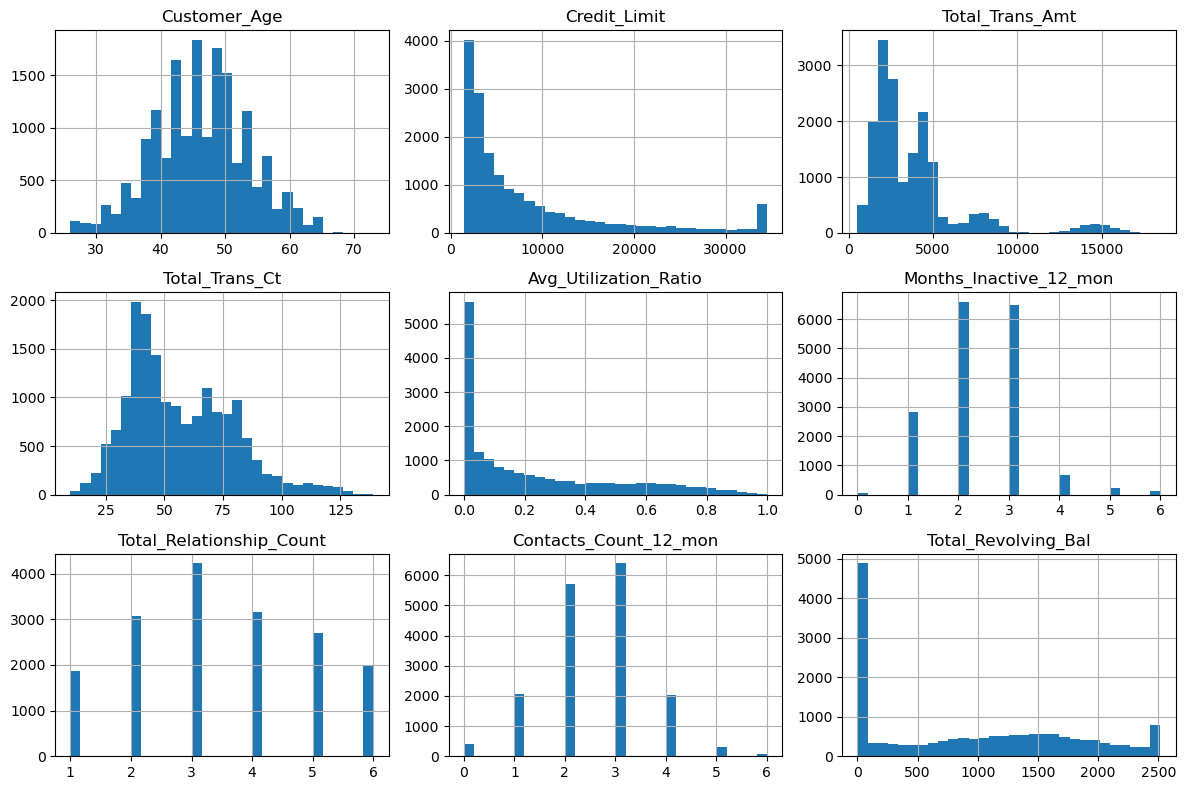

In [11]:
plotting_numerics= ['Customer_Age','Credit_Limit','Total_Trans_Amt','Total_Trans_Ct','Avg_Utilization_Ratio','Months_Inactive_12_mon','Total_Relationship_Count','Contacts_Count_12_mon','Total_Revolving_Bal']
df[plotting_numerics].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

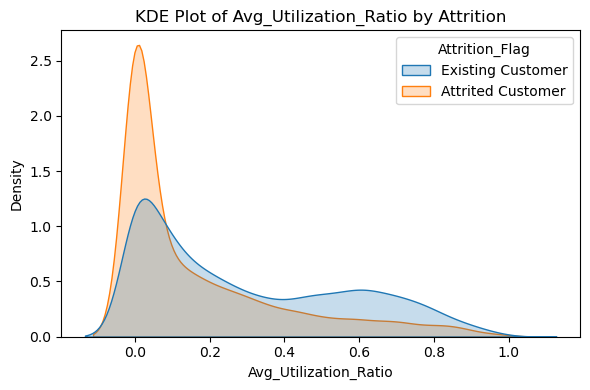

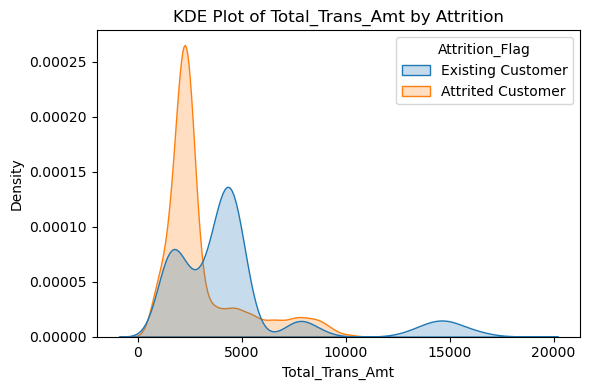

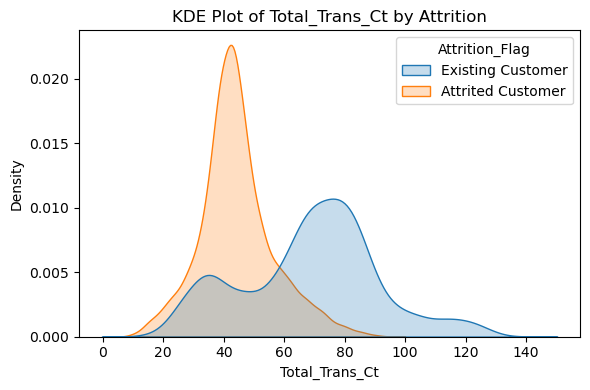

In [12]:
kde_features = ['Avg_Utilization_Ratio', 'Total_Trans_Amt', 'Total_Trans_Ct']

for i in kde_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=i, hue='Attrition_Flag', fill=True)
    plt.title(f'KDE Plot of {i} by Attrition')
    plt.tight_layout()
    plt.show()

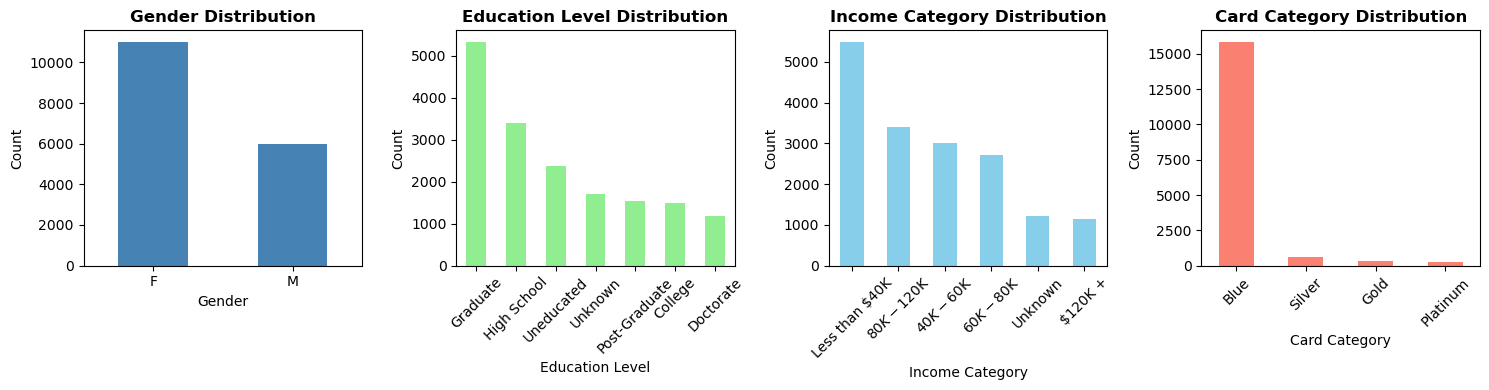

In [13]:
#Categorical distributions in one figure
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

#Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)

#Education Level
df['Education_Level'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Education Level Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

#Income Category
df['Income_Category'].value_counts().plot(kind='bar', ax=axes[2], color='skyblue')
axes[2].set_title('Income Category Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Income Category', fontsize=10)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

#Card Category
df['Card_Category'].value_counts().plot(kind='bar', ax=axes[3], color='salmon')
axes[3].set_title('Card Category Distribution', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Card Category', fontsize=10)
axes[3].set_ylabel('Count', fontsize=10)
axes[3].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


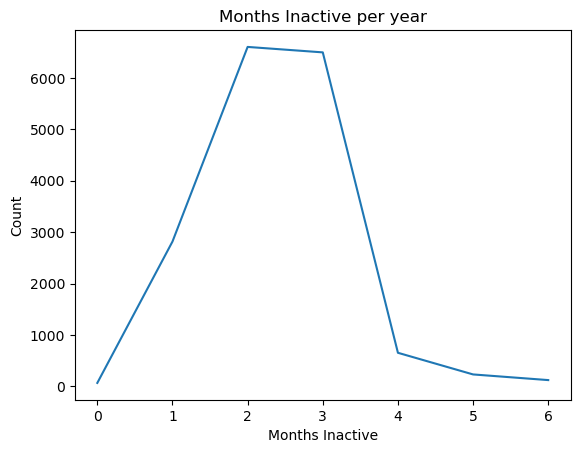

In [14]:
plt.figure()
df['Months_Inactive_12_mon'].value_counts().sort_index().plot(kind='line')
plt.title('Months Inactive per year')
plt.xlabel('Months Inactive')
plt.ylabel('Count')
plt.show()

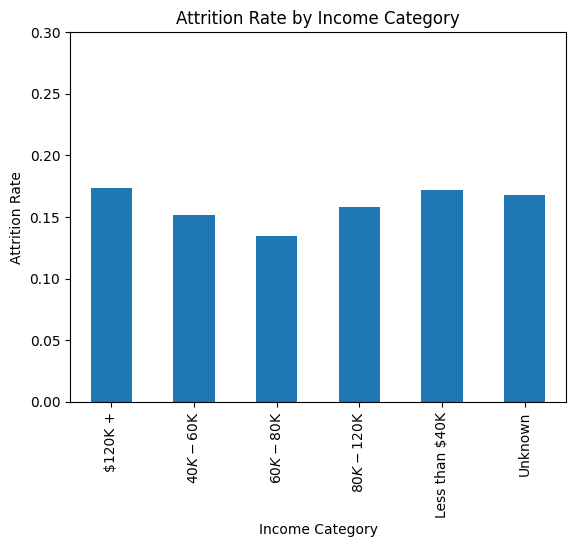

In [29]:
income_attr = (pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index')
    ['Attrited Customer']
)

plt.figure()
income_attr.plot(kind='bar')
plt.title('Attrition Rate by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Attrition Rate')
plt.ylim(0, 0.3)
plt.show()

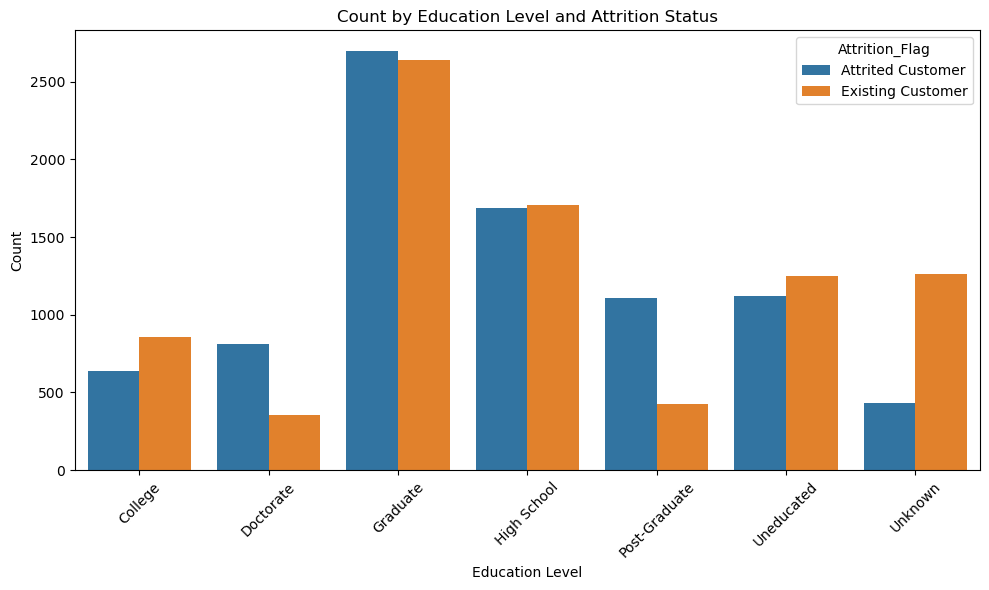

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 6))
edu_counts = df.groupby(['Education_Level', 'Attrition_Flag']).size().reset_index(name='Count')
sns.barplot(data=edu_counts, x='Education_Level', y='Count', hue='Attrition_Flag')
plt.title('Count by Education Level and Attrition Status')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df['Utilization_Level'] = pd.qcut(
    df['Avg_Utilization_Ratio'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['Transaction_Amount_Level'] = pd.qcut(
    df['Total_Trans_Amt'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['Transaction_Count_Level'] = pd.qcut(
    df['Total_Trans_Ct'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['Inactivity_Level'] = pd.cut(
    df['Months_Inactive_12_mon'],
    bins=[-1, 1, 3, df['Months_Inactive_12_mon'].max()],
    labels=['Few', 'Moderate', 'Many']
)

df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[0, 30, 55, df['Customer_Age'].max()],
    labels=['Adult', 'Mildlife', 'Elderly']
)
#Print count of each level for new cat features
for col in ['Utilization_Level','Transaction_Amount_Level','Transaction_Count_Level','Inactivity_Level','Age_Group']:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())



Utilization_Level:
Utilization_Level
Low       5673
Medium    5661
High      5666
Name: count, dtype: int64

Transaction_Amount_Level:
Transaction_Amount_Level
Low       5672
Medium    5664
High      5664
Name: count, dtype: int64

Transaction_Count_Level:
Transaction_Count_Level
Low       5985
Medium    5483
High      5532
Name: count, dtype: int64

Inactivity_Level:
Inactivity_Level
Few          2887
Moderate    13100
Many         1013
Name: count, dtype: int64

Age_Group:
Age_Group
Adult         306
Mildlife    14870
Elderly      1824
Name: count, dtype: int64
